# YPc2 LDOS Demo

This notebook compares STM images using the YPc2 ring-orbital LDOS model versus the atom-based LDOS (FePc).

In [1]:
import sys
from pathlib import Path

# Add parent directory to path to import stm_sim
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from stm_sim.config import SimulationConfig
from stm_sim.simulator import generate_sample


In [21]:
# --- YPc2: ring-orbital LDOS ---
cfg_ypc2 = SimulationConfig(seed=123)
cfg_ypc2.features.molecule_name = "YPc2"
cfg_ypc2.features.molecule_count = (1, 1)
cfg_ypc2.features.molecule_height = 2.0

# reduce noise to make the ring-orbital visible
cfg_ypc2.noise.tip_sigma = (0.5, 1.2)
cfg_ypc2.noise.gaussian_noise_sigma = (0.0, 0.0)
cfg_ypc2.noise.line_noise_sigma = (0.0, 0.0)
cfg_ypc2.noise.height_jitter_sigma = (0.0, 0.0)
cfg_ypc2.noise.tip_instability = (0.0, 0.0)
cfg_ypc2.noise.drift_shear = (0.0, 0.0)
cfg_ypc2.stm.setpoint_range = (0.005, 0.005)
cfg_ypc2.ldos.A_molecule = 1.0

# ring-orbital parameters (Angstroms)
cfg_ypc2.ldos.ypc2_r0 = 5.8
cfg_ypc2.ldos.ypc2_sig_r = 1.75
cfg_ypc2.ldos.ypc2_ang_mix = 0.0
cfg_ypc2.ldos.ypc2_center_amp = 1.2
cfg_ypc2.ldos.ypc2_center_kappa = 3
cfg_ypc2.features.molecule_height = 5.0

img_ypc2, mask_ypc2, meta_ypc2 = generate_sample(cfg_ypc2, seed=1)


In [3]:
# --- FePc: atom-based LDOS ---
cfg_fepc = SimulationConfig(seed=123)
cfg_fepc.features.molecule_name = "FePc"
cfg_fepc.features.molecule_count = (1, 1)
cfg_fepc.features.molecule_height = 2.0

img_fepc, mask_fepc, meta_fepc = generate_sample(cfg_fepc, seed=1)


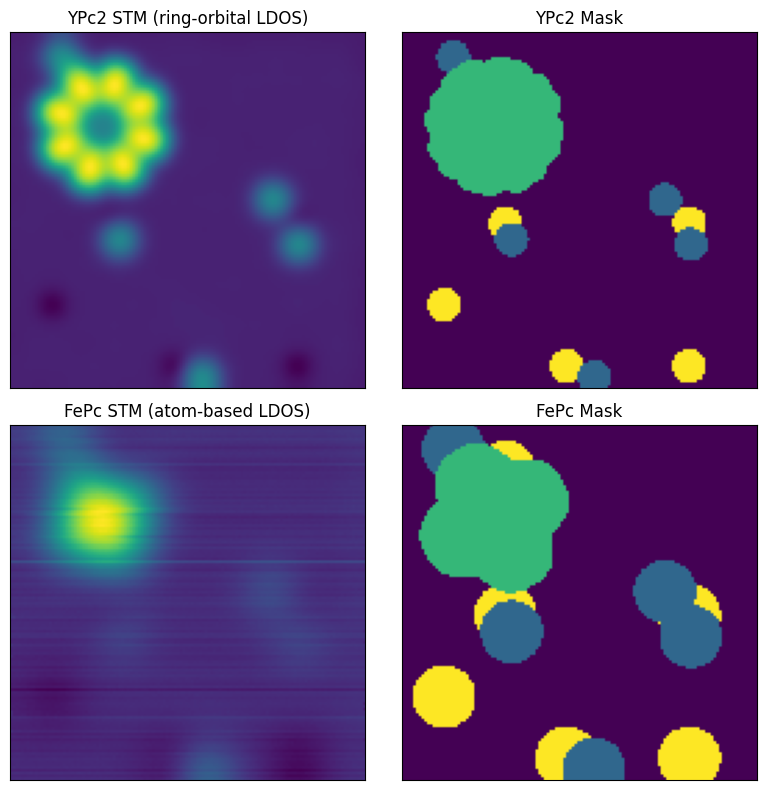

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(img_ypc2, origin="lower")
axes[0, 0].set_title("YPc2 STM (ring-orbital LDOS)")
axes[0, 1].imshow(mask_ypc2, origin="lower")
axes[0, 1].set_title("YPc2 Mask")
axes[1, 0].imshow(img_fepc, origin="lower")
axes[1, 0].set_title("FePc STM (atom-based LDOS)")
axes[1, 1].imshow(mask_fepc, origin="lower")
axes[1, 1].set_title("FePc Mask")
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
